In [1]:
import matplotlib.pyplot as plt

from utils_analysis_by_step_pred import load_prediction_results, remove_punctuation
from utils_analysis_by_batch import compute_percent_of_s2_covered_by_s1
from scipy.stats import spearmanr

folder = "eng_fil"
language_code = "tl"

In [2]:
data = load_prediction_results(
    folder, "ordering_results_pred_by_step_bs_1_1eps.json", run=0
)

In [3]:
def plot_hit_rate_vs_coverage_for_k(k: int):
    train_target_vocab = remove_punctuation(" ".join(data["train_targets"][: k + 1]))
    coverage_of_test_targets = [
        compute_percent_of_s2_covered_by_s1(
            s1=train_target_vocab, s2=remove_punctuation(s)
        )
        for s in data["test_targets"]
    ]
    hit_rate_of_predictions = [
        compute_percent_of_s2_covered_by_s1(
            s1=remove_punctuation(p), s2=remove_punctuation(s)
        )
        for (p, s) in zip(data["predictions"][k], data["test_targets"])
    ]
    corr = spearmanr(coverage_of_test_targets, hit_rate_of_predictions).statistic
    plt.title(
        f"% Vocab Seen vs Learned\nTraining Idx {k}, Spearman Corr: {round(corr,2)}"
    )
    plt.scatter(x=coverage_of_test_targets, y=hit_rate_of_predictions)
    plt.xlabel("% Test Vocab Seen in Training Data")
    plt.ylabel("% Test Vocab Learned by Model")
    return corr

np.float64(0.0482232549825173)

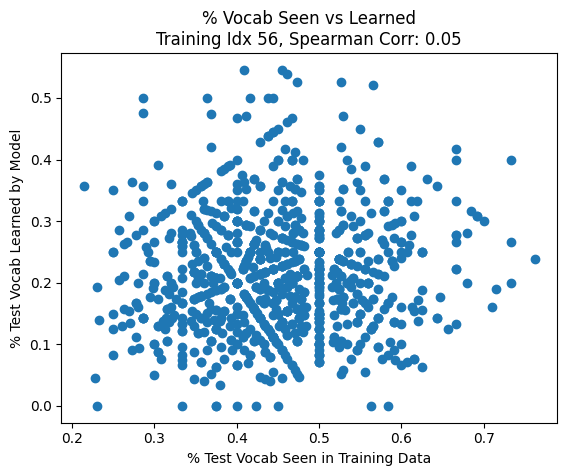

In [4]:
plot_hit_rate_vs_coverage_for_k(56)